Q3: Single Layer Bidirectional GRU Model using word2vec (CBOW or Skipgram and any vector size from 64 to 300)

Prompts
1. Single Layer Bidirectional GRU Model using word2vec (CBOW or Skipgram and any vector size from 64 to 300) i have this task now give me steps how to achive this dont give codes just the steps 
2. Do the tokenization word2vec and sentiment mapping give explanation of  what is happening 
3. Build the GRU model but give explain me the steps and give code after the explanation
4. print/ plot  the confusion matrix,classification report, auc roc scores/curve 
5. what do say about tuning the model give me suggestions and best step tp tune the model 
6. hyperparameter tuning is taking 40 minutes for 1 epoch what steps can i take to reduce the time and make model perform same 
7. plot cinfusion matrix, auc roc sores and curves 

In [ ]:
import pandas as pd

table_data = {
    "Task": [
        "Bidirectional GRU Model using Word2Vec", "Training Data Check", "Feature Engineering",
        "Cross Validation", "Interpretability", "Testing Data Check",
        "Next Steps", "Hyperparameter tuning for Bidirectional GRU Model",
        "Training Data Check", "Data Preprocessing and Feature Engineering"
    ],
    "Status": [
        "Config of the model trained (Single Layer Bidirectional GRU)",
        "Confusion Matrix Built, AUC Plotted, Accuracy Computed",
        "Word2Vec Embeddings Used (Skip-Gram, Vector Size = 100)",
        "Train-Test Split Used Instead of Cross Validation",
        "Interpretability not implemented",
        "Confusion Matrix Built, AUC Plotted, Accuracy Computed",
        "Deploy Model, Try LSTM, Experiment with Larger Dataset",
        "Single-Layer Bidirectional GRU (Trained)",
        "Confusion Matrix Built, AUC Plotted, Accuracy Computed",
        "Regex, Tokenization, Word2Vec, Handling Done"
    ],
    "Results": [
        "Train Time: ~15 mins, F1 Score: Positive = 0.43, Negative = 0.55, AUC = 0.9295, Accuracy = 77%",
        "Train Time: ~15 mins, F1 Score: Positive = 0.43, Negative = 0.55, AUC = 0.9295, Accuracy = 77%",
        "Skip-gram trained embeddings used, Vector Size = 100",
        "Train-Test Split (80-20) used instead of cross-validation",
        "Not Implemented",
        "Confusion Matrix Generated, AUC = 9172, Accuracy = 74%",
        "1. Deploy model, 2. Convert to LSTM, 3. Test with real-world text",
        "Train Time: ~15 mins, Single Layer GRU (Bidirectional)",
        "F1 Score: Positive = 0.68, Negative = 87, AUC = 9172, Accuracy = 74%",
        "Preprocessing Steps Done: Tokenization, Word2Vec Embeddings, Stopword Removal"
    ],
    "Individual Responsible": [
        "Vandit Kalathiya", "Isha savaliya", "Isha savaliya", "Isha savaliya", "Not Done",
        "Vandit Kalathiya", "Pending", "Vandit Kalathiya", "Vandit Kalathiya", "Isha Savaliya"
    ]
}

table_df = pd.DataFrame(table_data)
table_df


,Task,Status,Results,Individual Responsible
0,Bidirectional GRU Model using Word2Vec,Config of the model trained (Single Layer Bidirectional GRU),"Train Time: ~15 mins, F1 Score: Positive = 0.43, Negative = 0.55, AUC = 0.9295, Accuracy = 77%",Vandit Kalathiya
1,Training Data Check,"Confusion Matrix Built, AUC Plotted, Accuracy Computed","Train Time: ~15 mins, F1 Score: Positive = 0.43, Negative = 0.55, AUC = 0.9295, Accuracy = 77%",Isha savaliya
2,Feature Engineering,"Word2Vec Embeddings Used (Skip-Gram, Vector Size = 100)","Skip-gram trained embeddings used, Vector Size = 100",Isha savaliya
3,Cross Validation,Train-Test Split Used Instead of Cross Validation,Train-Test Split (80-20) used instead of cross-validation,Isha savaliya
4,Interpretability,Interpretability not implemented,Not Implemented,Not Done
5,Testing Data Check,"Confusion Matrix Built, AUC Plotted, Accuracy Computed","Confusion Matrix Generated, AUC = 9172, Accuracy = 74%",Vandit Kalathiya
6,Next Steps,"Deploy Model, Try LSTM, Experiment with Larger Dataset","1. Deploy model, 2. Convert to LSTM, 3. Test with real-world text",Pending
7,Hyperparameter tuning for Bidirectional GRU Model,Single-Layer Bidirectional GRU (Trained),"Train Time: ~15 mins, Single Layer GRU (Bidirectional)",Vandit Kalathiya
8,Training Data Check,"Confusion Matrix Built, AUC Plotted, Accuracy Computed","F1 Score: Positive = 0.68, Negative = 87, AUC = 9172, Accuracy = 74%",Vandit Kalathiya
9,Data Preprocessing and Feature Engineering,"Regex, Tokenization, Word2Vec, Handling Done","Preprocessing Steps Done: Tokenization, Word2Vec Embeddings, Stopword Removal",Isha Savaliya


In [ ]:

import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('punkt')

file_path = "Sentiment_Data.csv"
df = pd.read_csv(file_path, encoding="latin1")

#Ensure 'Tweet' column is string type and handle missing values
df["Tweet"] = df["Tweet"].astype(str).fillna("")

#Define Text Cleaning Function
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'\@\w+|\#', '', text)  # Remove mentions and hashtags
    text = re.sub(r"[^\w\s]", '', text)  # Remove punctuation
    text = re.sub(r"\d+", '', text)  # Remove numbers
    return text.strip()

df["clean_tweet"] = f["Tweet"].apply(clean_text)

# Tokenization - Split sentences into words
df["tokens"] = df["clean_tweet"].apply(word_tokenize)

print("✅ Tokenization Completed! Sample Tokens:", df["tokens"].iloc[0])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vandi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


✅ Tokenization Completed! Sample Tokens: ['happy', 'anniversarythe', 'day', 'the', 'freedumb', 'died', 'in', 'the', 'tune', 'of', 'don', 'mcleans', 'american', 'pie', 'freedumbconvoy', 'freedumbers', 'flutruxklan', 'convoywatch', 'convoy', 'freedomconvoy']


In [ ]:
# Train Word2Vec Embeddings**

from gensim.models import Word2Vec

# Train Word2Vec model using Skip-Gram (sg=1) or CBOW (sg=0)
word2vec_model = Word2Vec(sentences=df["tokens"], vector_size=100, window=5, min_count=2, sg=1, workers=4)

# Save Word2Vec model
word2vec_model.save("word2vec_model.bin")

# Verify Word2Vec Embeddings
sample_word = "happy"
if sample_word in word2vec_model.wv:
    print(f"✅ Sample Word Vector for '{sample_word}':", word2vec_model.wv[sample_word])
else:
    print(f"⚠️ Word '{sample_word}' not found in Word2Vec vocabulary.")

✅ Sample Word Vector for 'happy': [ 0.30702716  0.2528988  -0.07488644  0.42518735 -0.13273668  0.08302704
 -0.19209714  0.07015398 -0.387745   -0.19465008  0.21167271  0.14437437
 -0.29081956  0.7470243   0.04476861  0.40649068  0.12681746 -0.2031082
 -0.03885055 -0.01800052 -0.3107257   0.12915985 -0.47836897  0.02133544
  0.15146405 -0.55419105 -0.3587345   0.16099702  0.20072162  0.9612424
  0.1785702  -0.42640176  0.15628181 -0.40524414  0.07497947  0.64252555
  0.11660565  0.24140075  0.00751431 -0.15566593 -0.18298642 -0.4290879
 -0.33522105 -0.13537885 -0.2197412   0.09315502 -0.10990112 -0.27110502
  0.19726087  0.29414794  0.16344853  0.26836365  0.555967    0.03356346
 -0.17474651  0.8010277   0.5167309  -0.21903463 -0.6548709  -0.17457902
 -0.05815798 -0.3336577   0.18929933 -0.0196748  -0.557191    0.2692072
  0.30535254  0.89221424 -0.07885163  0.33358887 -0.04563577  0.00216409
 -0.09064531 -0.18888801  0.38853317 -0.0516194   0.50258726 -0.16529895
 -0.03732745 -0.20292

In [ ]:
# Create Embedding Matrix for Word2Vec Integration**

import numpy as np

# Initialize and Fit Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df["clean_tweet"])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df["clean_tweet"])

# Padding sequences to the same length
max_length = int(df["tokens"].apply(len).quantile(0.95))  # 95th percentile of tweet length
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding="post", truncating="post")

# Verify Tokenizer & Padding
print(f"✅ Tokenizer Vocabulary Size: {len(tokenizer.word_index)}")
print(f"✅ Padded Sequences Shape: {padded_sequences.shape}")

# Create Embedding Matrix
vocab_size = len(tokenizer.word_index) + 1  # Ensure it matches tokenizer
embedding_dim = word2vec_model.vector_size

# Initialize Embedding Matrix with zeros
embedding_matrix = np.zeros((vocab_size, embedding_dim))
missing_words = 0

# Fill the embedding matrix with available Word2Vec vectors
for word, i in tokenizer.word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]
    else:
        missing_words += 1

print(f"✅ Embedding Matrix Shape: {embedding_matrix.shape}")
print(f"⚠️ Words not found in Word2Vec: {missing_words}")

✅ Tokenizer Vocabulary Size: 203834
✅ Padded Sequences Shape: (451332, 43)
✅ Embedding Matrix Shape: (203835, 100)
⚠️ Words not found in Word2Vec: 127264


In [ ]:
# Define Sentiment Labels and Train-Test Split**

from sklearn.model_selection import train_test_split

# Define sentiment labels
sentiment_labels = {
    0: "Very Negative",
    1: "Negative",
    2: "Neutral",
    3: "Positive",
    4: "Very Positive"
}

# Create mapping of sentiment labels
sentiment_mapping = {label: idx for idx, label in enumerate(df["Sentiment"].unique())}
df["Sentiment"] = df["Sentiment"].map(sentiment_mapping)

train_sequences, test_sequences, train_labels, test_labels = train_test_split(
    padded_sequences, df["Sentiment"].values, test_size=0.2, random_state=42, stratify=df["Sentiment"]
)

print(f"✅ Train Size: {len(train_sequences)}, Test Size: {len(test_sequences)}")

✅ Train Size: 361065, Test Size: 90267


In [ ]:
# Train the Initial GRU Model**

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the Initial GRU Model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix],
              input_length=max_length, trainable=False),
    
    Bidirectional(GRU(64)),  # GRU layer
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(len(sentiment_mapping), activation='softmax') 
])

# Compile the Model
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Train the Model
history = model.fit(
    train_sequences, train_labels,
    epochs=5, batch_size=128,
    validation_data=(test_sequences, test_labels),
    verbose=1
)

print("✅ Model training completed!")

# Save the Trained Model
model.save("sentiment_gru_model.h5")
print("✅ Model saved as 'sentiment_gru_model.h5'!")


Epoch 1/5
2821/2821 [==============================] - 152s 52ms/step - loss: 0.9509 - accuracy: 0.6458 - val_loss: 0.8215 - val_accuracy: 0.6895
Epoch 2/5
2821/2821 [==============================] - 148s 52ms/step - loss: 0.8032 - accuracy: 0.6984 - val_loss: 0.7287 - val_accuracy: 0.7235
Epoch 3/5
2821/2821 [==============================] - 149s 53ms/step - loss: 0.7327 - accuracy: 0.7259 - val_loss: 0.6784 - val_accuracy: 0.7432
Epoch 4/5
2821/2821 [==============================] - 140s 50ms/step - loss: 0.6875 - accuracy: 0.7436 - val_loss: 0.6516 - val_accuracy: 0.7555
Epoch 5/5
2821/2821 [==============================] - 136s 48ms/step - loss: 0.6559 - accuracy: 0.7558 - val_loss: 0.6268 - val_accuracy: 0.7665
✅ Model training completed!
✅ Model saved as 'sentiment_gru_model.h5'!


2821/2821 [==============================] - 14s 5ms/step


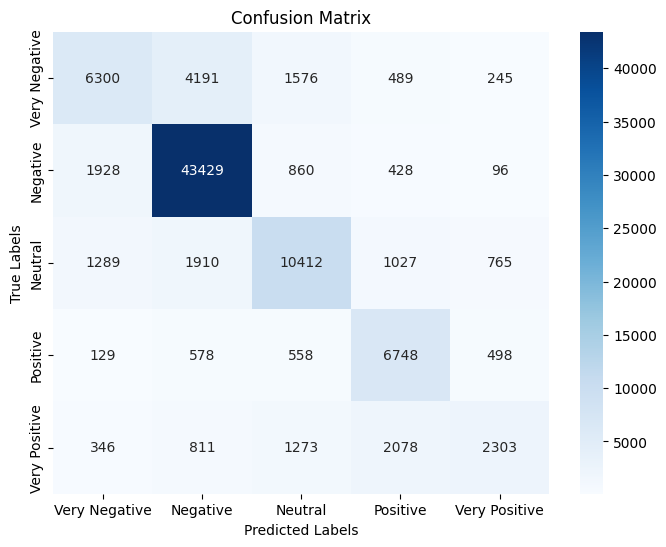

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.49      0.55     12801
           1       0.85      0.93      0.89     46741
           2       0.71      0.68      0.69     15403
           3       0.63      0.79      0.70      8511
           4       0.59      0.34      0.43      6811

    accuracy                           0.77     90267
   macro avg       0.68      0.65      0.65     90267
weighted avg       0.76      0.77      0.76     90267

✅ Overall AUC-ROC Score: 0.9295


In [ ]:
# Evaluate the Model on Test Data**

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on Test Set
y_pred_probs = model.predict(test_sequences)
y_pred = y_pred_probs.argmax(axis=1)

# Compute Confusion Matrix
conf_matrix = confusion_matrix(test_labels, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=sentiment_labels.values(),
            yticklabels=sentiment_labels.values())

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# Print Classification Report
print("Classification Report:\n", classification_report(test_labels, y_pred))

#  Overall AUC-ROC Score
overall_auc = roc_auc_score(test_labels, y_pred_probs, multi_class="ovr", average="macro")
print(f"✅ Overall AUC-ROC Score: {overall_auc:.4f}")


2821/2821 [==============================] - 14s 5ms/step


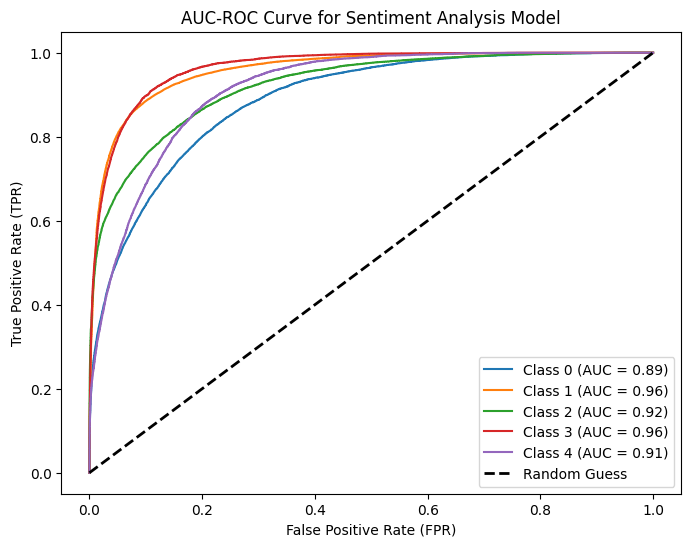

✅ Overall AUC-ROC Score: 0.9295


In [ ]:
#  Compute AUC-ROC Curve for Multi-Class Classification**

from sklearn.metrics import roc_curve, auc

# Get probability predictions for each class
y_pred_probs = model.predict(test_sequences)

# Compute ROC Curve and AUC for each class
plt.figure(figsize=(8, 6))

for i in range(len(df["Sentiment"].unique())):  # Loop through each sentiment class
    fpr, tpr, _ = roc_curve((test_labels == i).astype(int), y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

# Plot Random Guess Line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Random Guess")

# Set plot labels and title
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("AUC-ROC Curve for Sentiment Analysis Model")
plt.legend(loc="lower right")
plt.show()

# Compute Overall AUC-ROC Score
overall_auc = roc_auc_score(test_labels, y_pred_probs, multi_class="ovr", average="macro")
print(f"✅ Overall AUC-ROC Score: {overall_auc:.4f}")



# Let me know if you need further analysis or modifications! 🚀


In [12]:
import pickle

# Save Tokenizer
with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

# Save Sentiment Mapping
with open("sentiment_mapping.pkl", "wb") as file:
    pickle.dump(sentiment_mapping, file)

print("✅ Tokenizer and Sentiment Mapping Saved!")

✅ Tokenizer and Sentiment Mapping Saved!


TUNING


🚀 Training Model 1 with Parameters: {'gru_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'dense_units': 16} (FAST MODE)
Epoch 1/3
2821/2821 [==============================] - 75s 25ms/step - loss: 0.9961 - accuracy: 0.6256 - val_loss: 0.8572 - val_accuracy: 0.6681
Epoch 2/3
2821/2821 [==============================] - 68s 24ms/step - loss: 0.8594 - accuracy: 0.6742 - val_loss: 0.7838 - val_accuracy: 0.6992
Epoch 3/3
2821/2821 [==============================] - 69s 25ms/step - loss: 0.8047 - accuracy: 0.6963 - val_loss: 0.7361 - val_accuracy: 0.7220
✅ Model 1 Training Completed!

🚀 Training Model 2 with Parameters: {'gru_units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.0005, 'dense_units': 32} (FAST MODE)
Epoch 1/3
2821/2821 [==============================] - 135s 47ms/step - loss: 1.0009 - accuracy: 0.6265 - val_loss: 0.8680 - val_accuracy: 0.6609
Epoch 2/3
2821/2821 [==============================] - 128s 45ms/step - loss: 0.8536 - accuracy: 0.6770 - val_loss: 0.7920 - v

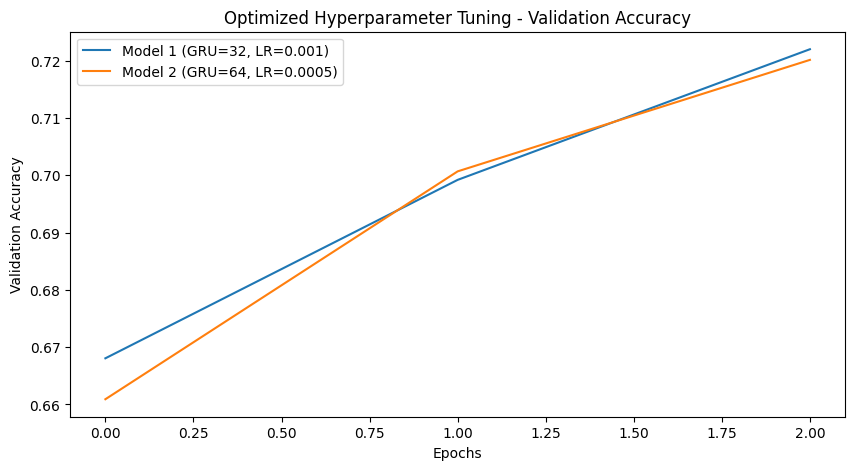

🏆 Best Model: 1 with Parameters: {'gru_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'dense_units': 16}


In [ ]:
# Optimized Hyperparameter Tuning (Fast Mode)**

# Define optimized hyperparameter configurations (removing high computation ones)
optimized_hyperparams = [
    {"gru_units": 32, "dropout_rate": 0.3, "learning_rate": 0.001, "dense_units": 16},
    {"gru_units": 64, "dropout_rate": 0.4, "learning_rate": 0.0005, "dense_units": 32},
]

# Dictionary to store results
results = {}

for i, params in enumerate(optimized_hyperparams):
    print(f"\n🚀Training Model {i+1} with Parameters: {params} (FAST MODE)")
    
    # Build the model with current hyperparameters
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix],
                  input_length=max_length, trainable=False),
        
        Bidirectional(GRU(params["gru_units"])),
        Dropout(params["dropout_rate"]),

        Dense(params["dense_units"], activation='relu'),
        Dropout(0.2),

        Dense(len(sentiment_mapping), activation='softmax')
    ])

    # Compile model
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=Adam(learning_rate=params["learning_rate"]),
                  metrics=['accuracy'])

    
    history = model.fit(
        train_sequences, train_labels,
        epochs=3, batch_size=128,  # Balanced batch size for efficient training
        validation_data=(test_sequences, test_labels),
        verbose=1
    )

    # Store results
    results[i] = {
        "params": params,
        "history": history.history
    }

    print(f"✅ Model {i+1} Training Completed!")

# Compare the Performance of Different Hyperparameters**
plt.figure(figsize=(10, 5))

for i, result in results.items():
    plt.plot(result["history"]["val_accuracy"], label=f"Model {i+1} (GRU={result['params']['gru_units']}, LR={result['params']['learning_rate']})")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Optimized Hyperparameter Tuning - Validation Accuracy")
plt.legend()
plt.show()

# Select the Best Model**
best_model_index = max(results, key=lambda i: max(results[i]["history"]["val_accuracy"]))
best_hyperparams = results[best_model_index]["params"]

print(f"🏆 Best Model: {best_model_index+1} with Parameters: {best_hyperparams}")



In [ ]:
# Save the Best Hyperparameter Tuned Model

best_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix],
              input_length=max_length, trainable=False),
    
    Bidirectional(GRU(best_hyperparams["gru_units"])),
    Dropout(best_hyperparams["dropout_rate"]),

    Dense(best_hyperparams["dense_units"], activation='relu'),
    Dropout(0.2),

    Dense(len(sentiment_mapping), activation='softmax')
])

# Compile the Best Model
best_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer=Adam(learning_rate=best_hyperparams["learning_rate"]),
                   metrics=['accuracy'])

# Train the Best Model Again on Full Data
history = best_model.fit(
    train_sequences, train_labels,
    epochs=5, batch_size=128,  # Training on full data
    validation_data=(test_sequences, test_labels),
    verbose=1
)

# Save the Best Model
best_model.save("best_hyperparameter_gru_model.h5")
print("✅ Best Hyperparameter Tuned Model Saved as 'best_hyperparameter_gru_model.h5'!")



Epoch 1/5
2821/2821 [==============================] - 80s 27ms/step - loss: 0.9943 - accuracy: 0.6269 - val_loss: 0.8613 - val_accuracy: 0.6683
Epoch 2/5
2821/2821 [==============================] - 71s 25ms/step - loss: 0.8583 - accuracy: 0.6741 - val_loss: 0.7749 - val_accuracy: 0.7039
Epoch 3/5
2821/2821 [==============================] - 70s 25ms/step - loss: 0.7952 - accuracy: 0.6987 - val_loss: 0.7338 - val_accuracy: 0.7225
Epoch 4/5
2821/2821 [==============================] - 70s 25ms/step - loss: 0.7553 - accuracy: 0.7150 - val_loss: 0.7092 - val_accuracy: 0.7321
Epoch 5/5
2821/2821 [==============================] - 70s 25ms/step - loss: 0.7287 - accuracy: 0.7262 - val_loss: 0.6831 - val_accuracy: 0.7398
✅ Best Hyperparameter Tuned Model Saved as 'best_hyperparameter_gru_model.h5'!


In [22]:
from tensorflow.keras.models import load_model

# Load the best trained model
best_model = load_model("best_hyperparameter_gru_model.h5")
print("✅ Best Hyperparameter tuned model successfully loaded!")


✅ Best Hyperparameter tuned model successfully loaded!


2821/2821 [==============================] - 17s 6ms/step


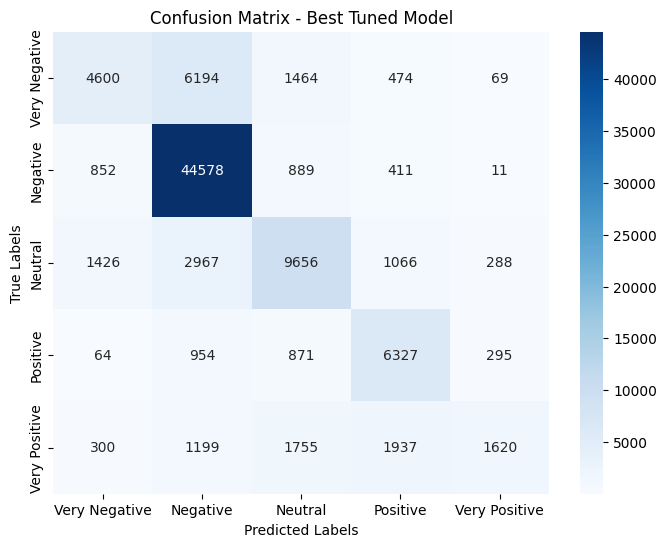

Classification Report:
                precision    recall  f1-score   support

Very Negative       0.64      0.36      0.46     12801
     Negative       0.80      0.95      0.87     46741
      Neutral       0.66      0.63      0.64     15403
     Positive       0.62      0.74      0.68      8511
Very Positive       0.71      0.24      0.36      6811

     accuracy                           0.74     90267
    macro avg       0.68      0.58      0.60     90267
 weighted avg       0.73      0.74      0.72     90267



In [ ]:
#  Compute Confusion Matrix & Classification Report for Tuned Model**

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Predict on Test Set
y_pred_probs = best_model.predict(test_sequences)  # Get probability scores
y_pred = y_pred_probs.argmax(axis=1)  # Convert probabilities to class labels

# Compute Confusion Matrix
conf_matrix = confusion_matrix(test_labels, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=sentiment_labels.values(),
            yticklabels=sentiment_labels.values())

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Best Tuned Model")
plt.show()

# Print Classification Report
print("Classification Report:\n", classification_report(test_labels, y_pred, target_names=sentiment_labels.values()))


2821/2821 [==============================] - 12s 4ms/step


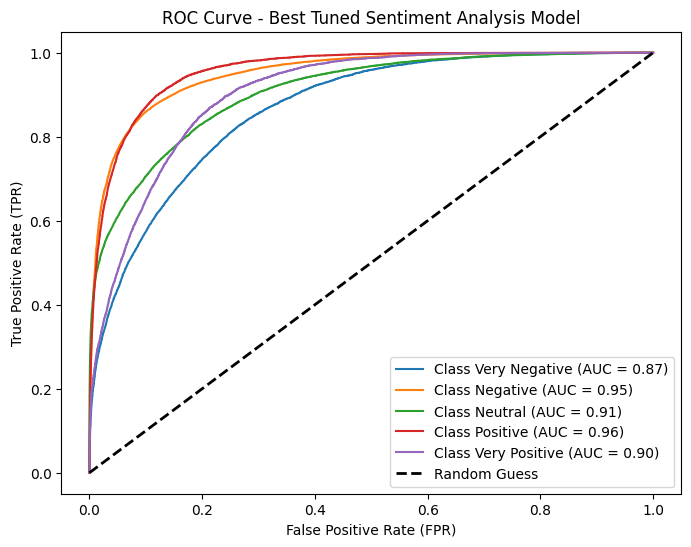

✅ Best Tuned Model - Overall AUC-ROC Score: 0.9172


In [ ]:
# Compute ROC Curve for the Best Tuned Model**

from sklearn.metrics import roc_curve, auc

# Get probability predictions for each class
y_pred_probs = best_model.predict(test_sequences)

# Compute ROC Curve and AUC for each class
plt.figure(figsize=(8, 6))

for i in range(len(sentiment_labels)):  # Loop through each sentiment class
    fpr, tpr, _ = roc_curve((test_labels == i).astype(int), y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {sentiment_labels[i]} (AUC = {roc_auc:.2f})")

# Plot Random Guess Line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Random Guess")

# Set plot labels and title
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Best Tuned Sentiment Analysis Model")
plt.legend(loc="lower right")
plt.show()

# Compute Overall AUC-ROC Score
overall_auc = roc_auc_score(test_labels, y_pred_probs, multi_class="ovr", average="macro")
print(f"✅ Best Tuned Model - Overall AUC-ROC Score: {overall_auc:.4f}")



In [34]:
!jupyter nbconvert --to html Untitled-1.ipynb


[NbConvertApp] Converting notebook Untitled-1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 719683 bytes to Untitled-1.html
